# **Часть 1 - Доделываем семинар и получаем SNP**

Выполнив задание семинара 8, получаем SNP.

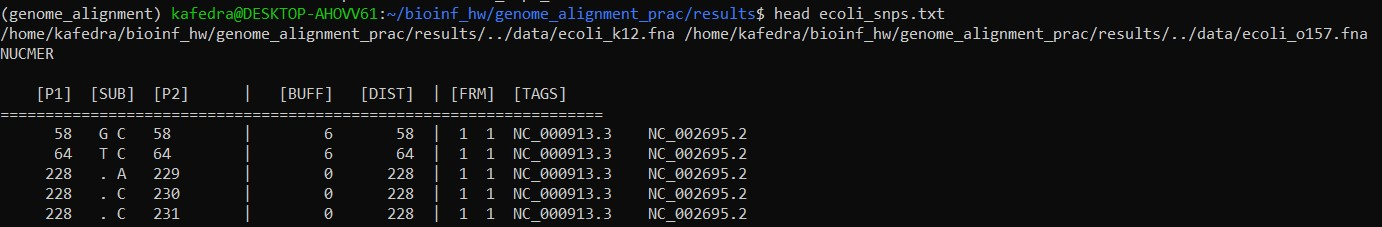

*Столбцы означают следующее:*

- P1 - позиция в первом геноме (E. coli K-12)

- SUB - нуклеотид в первом геноме и то, на что он заменен во втором геноме (точка означает, что в этой позиции нет нуклеотида)

- P2 - позиция во втором геноме (E. coli O157:H7)

- BUFF - расстояние до следующего SNP/вариации

- DIST - расстояние от ближайшего края выравнивания

- FRM - рамка считывания (показывает, в фазе или нет индел)

- TAGS - идентификаторы последовательностей из обоих файлов (номера доступов в GenBank)

# **Часть 2 - Аннотация SNP**

Скрипт будем писать на питоне (разумеется на вайбе).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from Bio import SeqIO
from Bio.Seq import Seq
import os
import urllib.request
import gzip
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. ЗАГРУЗКА SNP
# ============================================

def load_snps_from_detailed(detailed_file='ecoli_full_snps_detailed.txt'):
    snps = []
    with open(detailed_file, 'r') as f:
        lines = f.readlines()
    start_reading = False
    for line in lines:
        if line.startswith('=') or line.startswith('['):
            continue
        if line.startswith('NUCMER'):
            start_reading = True
            continue
        if not start_reading:
            continue
        parts = line.strip().split()
        if len(parts) < 7:
            continue
        try:
            ref_pos = int(parts[0])
            ref_base = parts[1]
            qry_base = parts[2]
            if ref_base != '.' and qry_base != '.' and ref_base != qry_base:
                snps.append({'pos': ref_pos, 'ref': ref_base, 'qry': qry_base})
        except:
            continue
    return pd.DataFrame(snps)

def load_snps_from_simple(simple_file='ecoli_full_snps.txt'):
    snps = []
    with open(simple_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('NUCMER'):
                continue
            parts = line.split()
            if len(parts) >= 3 and parts[0].isdigit():
                ref_base = parts[1]
                qry_base = parts[2]
                if ref_base != '.' and qry_base != '.' and ref_base != qry_base:
                    snps.append({'pos': int(parts[0]), 'ref': ref_base, 'qry': qry_base})
    return pd.DataFrame(snps)

# ============================================
# 2. ЗАГРУЗКА GENBANK
# ============================================

def download_genbank():
    gb_file = 'ecoli_k12.gbk'
    if os.path.exists(gb_file):
        return gb_file
    print("Скачиваю GenBank...")
    url = "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/GCF_000005845.2_ASM584v2/GCF_000005845.2_ASM584v2_genomic.gbff.gz"
    try:
        urllib.request.urlretrieve(url, 'temp.gbff.gz')
        with gzip.open('temp.gbff.gz', 'rb') as f_in:
            with open(gb_file, 'wb') as f_out:
                f_out.write(f_in.read())
        os.remove('temp.gbff.gz')
        return gb_file
    except:
        return None

def parse_cds_from_genbank(gb_file):
    if not gb_file or not os.path.exists(gb_file):
        return [], None
    cds_list = []
    record = SeqIO.read(gb_file, "genbank")
    for feature in record.features:
        if feature.type == 'CDS':
            gene_name = feature.qualifiers.get('gene', ['unknown'])[0]
            product = feature.qualifiers.get('product', ['unknown'])[0]
            cds_list.append({
                'name': gene_name,
                'product': product,
                'start': int(feature.location.start),
                'end': int(feature.location.end),
                'strand': feature.location.strand,
                'sequence': feature.extract(record.seq)
            })
    print(f"Загружено CDS: {len(cds_list)}")
    return cds_list, record

# ============================================
# 3. ОПРЕДЕЛЕНИЕ АМИНОКИСЛОТНОЙ ЗАМЕНЫ
# ============================================

def get_aa_change(pos, ref_base, qry_base, cds):
    if cds['strand'] == 1:
        cds_pos = pos - cds['start']
    else:
        cds_pos = cds['end'] - pos
    if cds_pos < 0 or cds_pos >= len(cds['sequence']):
        return "out_of_cds", "error"
    codon_index = cds_pos // 3
    within_codon = cds_pos % 3
    codon_start = codon_index * 3
    if codon_start + 3 > len(cds['sequence']):
        return "truncated", "error"
    original_codon = str(cds['sequence'][codon_start:codon_start+3])
    modified_codon_list = list(original_codon)
    modified_codon_list[within_codon] = qry_base
    modified_codon = ''.join(modified_codon_list)
    original_aa = Seq(original_codon).translate()
    modified_aa = Seq(modified_codon).translate()
    aa_position = codon_index + 1
    if original_aa == modified_aa:
        return f"p.{original_aa}{aa_position}{original_aa}", "synonymous"
    else:
        return f"p.{original_aa}{aa_position}{modified_aa}", "nonsynonymous"

# ============================================
# 4. СОКРАЩЁННЫЙ ФУНКЦИОНАЛЬНЫЙ КОММЕНТАРИЙ
# ============================================

def short_comment(row):
    if row['type'] == 'intergenic':
        return "межгенная область"
    elif row['type'] == 'synonymous':
        return "нейтральная замена"
    else:  # nonsynonymous
        return "возможно изменение белка"

def annotate_snps(snps_df, cds_list):
    annotated = []
    for _, row in snps_df.iterrows():
        pos = row['pos']
        ref = row['ref']
        qry = row['qry']
        gene_name = None
        product = None
        cds_info = None
        for cds in cds_list:
            if cds['start'] <= pos <= cds['end']:
                gene_name = cds['name']
                product = cds['product']
                cds_info = cds
                break
        if gene_name is None:
            entry = {
                'position': pos,
                'ref': ref,
                'qry': qry,
                'gene': 'intergenic',
                'product': '-',
                'type': 'intergenic',
                'aa_change': 'N/A'
            }
            entry['functional'] = short_comment(entry)
            annotated.append(entry)
        else:
            aa_change, snp_type = get_aa_change(pos, ref, qry, cds_info)
            if snp_type == 'error':
                continue
            entry = {
                'position': pos,
                'ref': ref,
                'qry': qry,
                'gene': gene_name,
                'product': product,
                'type': snp_type,
                'aa_change': aa_change
            }
            entry['functional'] = short_comment(entry)
            annotated.append(entry)
    return pd.DataFrame(annotated)

# ============================================
# 5. ВИЗУАЛИЗАЦИЯ
# ============================================

def plot_snp_type_distribution(annotated_df):
    """Круговая диаграмма для всех SNP: синонимичные, несинонимичные, межгенные"""
    def categorize(row):
        if row['gene'] == 'intergenic':
            return 'intergenic'
        else:
            return row['type']

    annotated_df['category'] = annotated_df.apply(categorize, axis=1)
    type_counts = annotated_df['category'].value_counts()
    type_counts = type_counts.rename(index={
        'synonymous': 'Синонимичные',
        'nonsynonymous': 'Несинонимичные',
        'intergenic': 'Межгенные'
    })

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    colors = ['#66b3ff', '#ff9999', '#99ff99']
    ax1.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors[:len(type_counts)], startangle=90)
    ax1.set_title('Распределение всех SNP', fontsize=12)
    ax2.bar(type_counts.index, type_counts.values, color=colors[:len(type_counts)], edgecolor='black')
    ax2.set_xlabel('Категория SNP')
    ax2.set_ylabel('Количество')
    ax2.set_title('Количество SNP по категориям')
    for i, v in enumerate(type_counts.values):
        ax2.text(i, v + max(type_counts.values)*0.01, str(v), ha='center')
    plt.tight_layout()
    plt.savefig('snp_type_distribution.png', dpi=150)
    plt.show()
    print("Сохранён snp_type_distribution.png (все SNP)")

def plot_top_genes_snps(annotated_df, top_n=10):
    coding = annotated_df[annotated_df['gene'] != 'intergenic']
    if len(coding) == 0:
        return
    gene_counts = coding['gene'].value_counts().head(top_n)
    plt.figure(figsize=(12, 6))
    plt.barh(range(len(gene_counts)), gene_counts.values, color='coral', edgecolor='black')
    plt.yticks(range(len(gene_counts)), gene_counts.index)
    plt.xlabel('Number of SNPs')
    plt.ylabel('Gene')
    plt.title(f'Top-{top_n} genes with most SNPs')
    for i, v in enumerate(gene_counts.values):
        plt.text(v + 0.5, i, str(v), va='center')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('top_genes_snps.png', dpi=150)
    plt.show()
    print("\nTop-10 genes:")
    print(gene_counts.to_string())

def plot_snp_density(annotated_df):
    coding = annotated_df[annotated_df['gene'] != 'intergenic']
    intergenic = annotated_df[annotated_df['gene'] == 'intergenic']
    plt.figure(figsize=(14, 6))
    bins = 100
    plt.hist(coding['position'], bins=bins, alpha=0.6, label='Coding', color='blue', edgecolor='black')
    plt.hist(intergenic['position'], bins=bins, alpha=0.6, label='Intergenic', color='orange', edgecolor='black')
    plt.xlabel('Genome position (bp)')
    plt.ylabel('Number of SNPs')
    plt.title('SNP density along E. coli K-12 genome')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('snp_density.png', dpi=150)
    plt.show()

# ============================================
# 6. MAIN
# ============================================

def main():
    print("="*70)
    print("PART 2: SNP ANNOTATION (short functional comments)")
    print("="*70)

    snp_files = ['ecoli_full_snps_detailed.txt', 'ecoli_full_snps.txt', 'ecoli_snps_detailed.txt', 'ecoli_snps.txt']
    snps_df = None
    for f in snp_files:
        if os.path.exists(f):
            print(f"Loading {f}...")
            if 'detailed' in f:
                snps_df = load_snps_from_detailed(f)
            else:
                snps_df = load_snps_from_simple(f)
            if len(snps_df) > 0:
                break
    if snps_df is None or len(snps_df) == 0:
        print("No SNPs found.")
        return
    print(f"Loaded {len(snps_df)} SNPs")

    print("\nHeader of SNP file (first 10 lines):")
    for f in snp_files:
        if os.path.exists(f):
            with open(f, 'r') as fo:
                for i, line in enumerate(fo):
                    if i >= 10: break
                    print(f"  {line.rstrip()}")
            break

    gb_file = download_genbank()
    if not gb_file:
        return
    cds_list, _ = parse_cds_from_genbank(gb_file)
    if not cds_list:
        return
    annotated_df = annotate_snps(snps_df, cds_list)
    print(f"Annotated: total {len(annotated_df)}, in genes {len(annotated_df[annotated_df['gene']!='intergenic'])}, intergenic {len(annotated_df[annotated_df['gene']=='intergenic'])}")
    annotated_df.to_csv('annotated_snps_short.csv', index=False)
    print("Saved annotated_snps_short.csv")

    print("\nFirst 10 rows with short functional comment:")
    print(annotated_df.head(10).to_string(index=False))

    plot_snp_type_distribution(annotated_df)
    plot_top_genes_snps(annotated_df)
    plot_snp_density(annotated_df)

    coding = annotated_df[annotated_df['gene'] != 'intergenic']
    if len(coding) > 0:
        ns = len(coding[coding['type']=='nonsynonymous'])
        syn = len(coding[coding['type']=='synonymous'])
        print(f"\nStatistics: synonymous={syn}, nonsynonymous={ns}, ratio={ns/syn if syn>0 else 0:.3f}")
    print("Done.")

if __name__ == "__main__":
    main()

Получаем вот такую ***аннотацию*** :

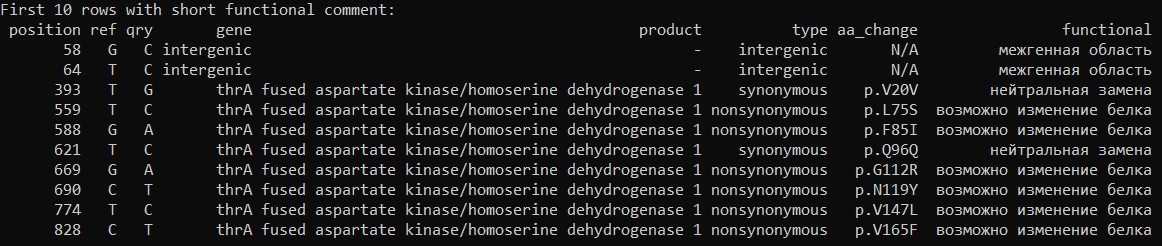

А также ***график плотности SNP с наложением позиций генов*** :

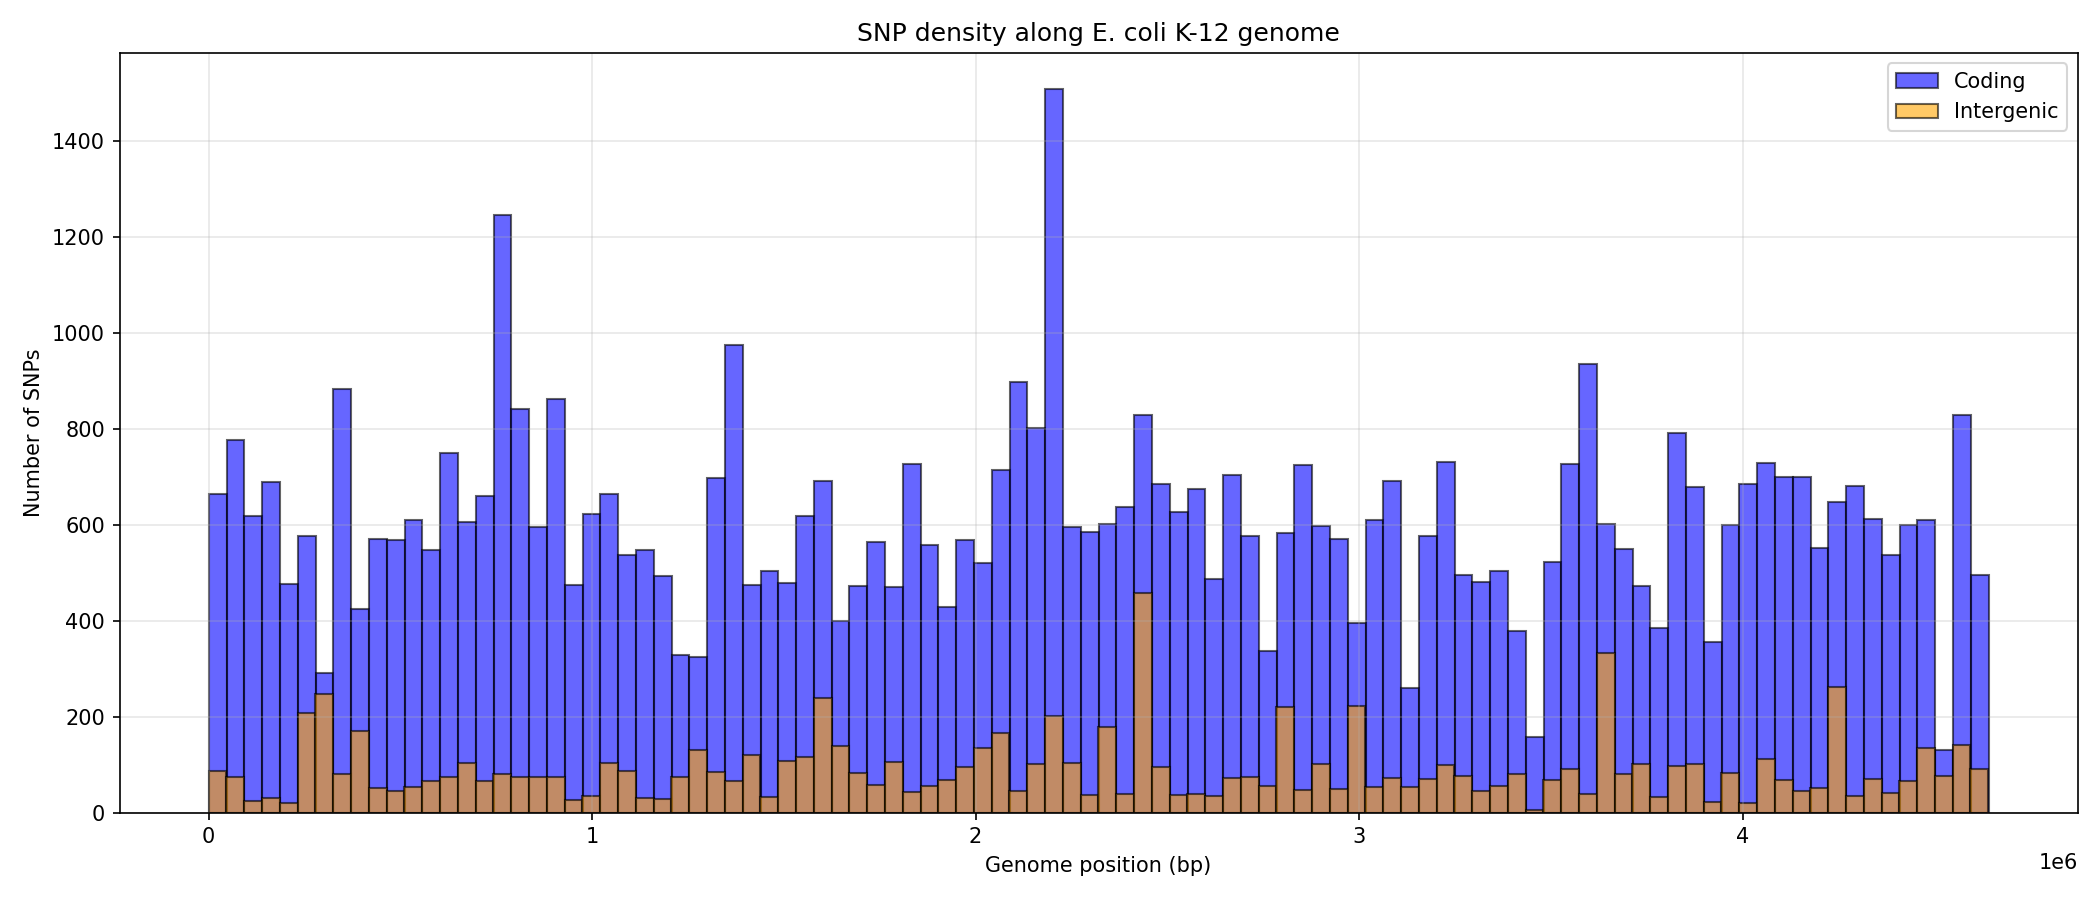

И ***диаграмму распределения типов SNP*** :

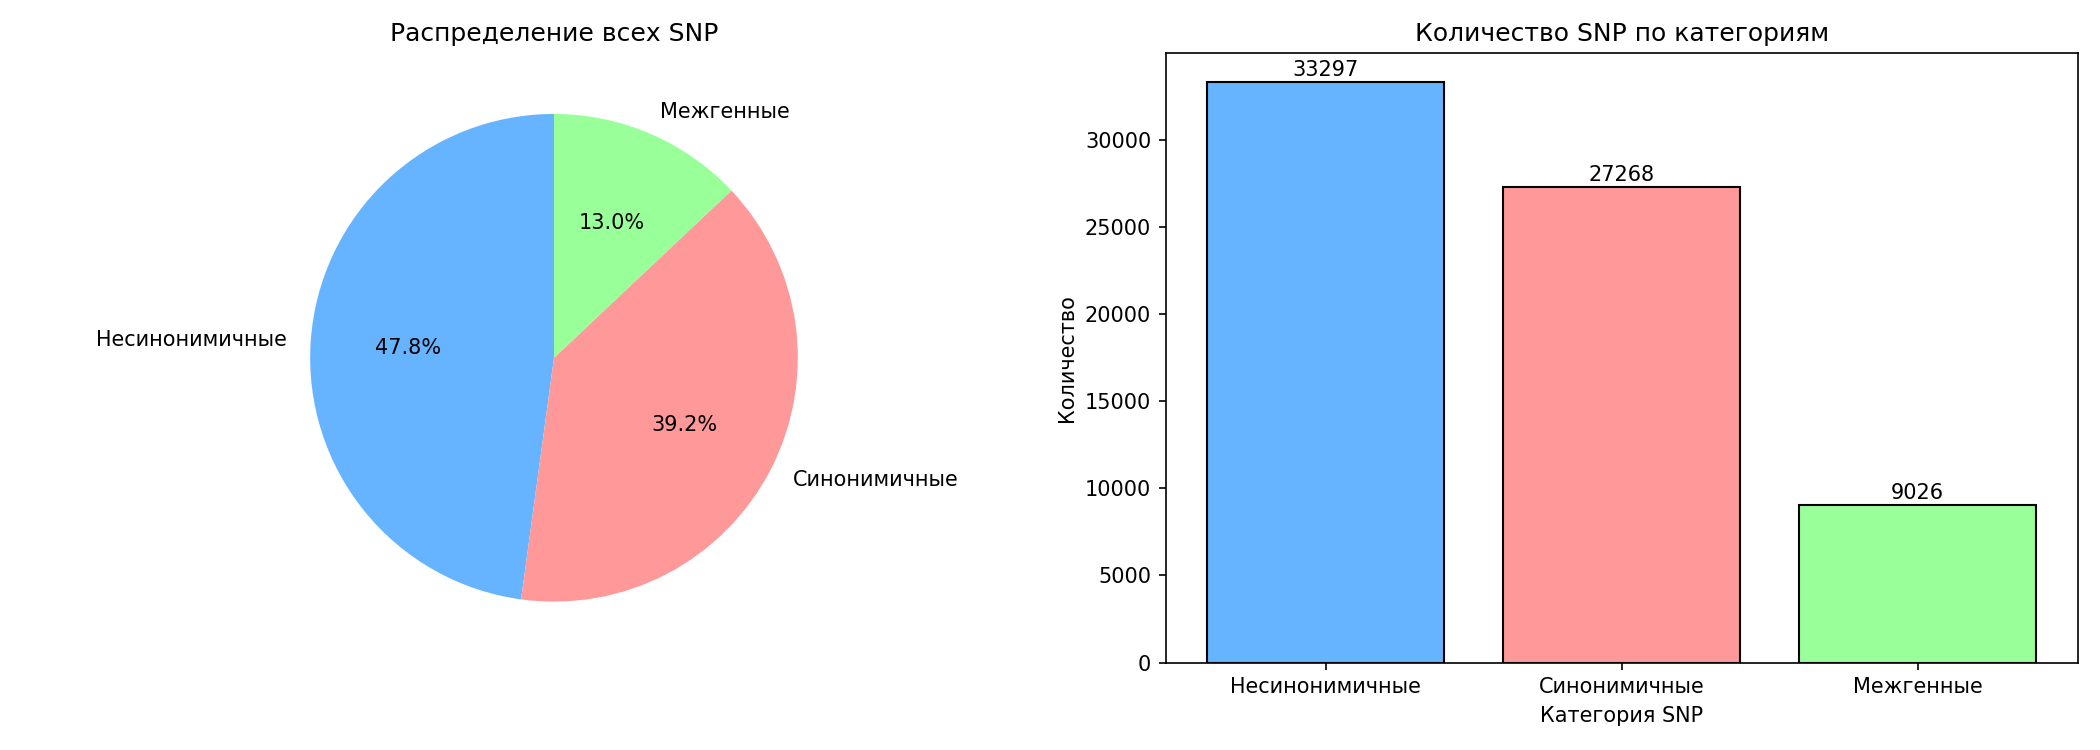

А вот ***таблица топ-10 генов с наибольшим количеством SNP*** :

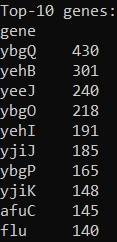

И соответствующая диаграмма:

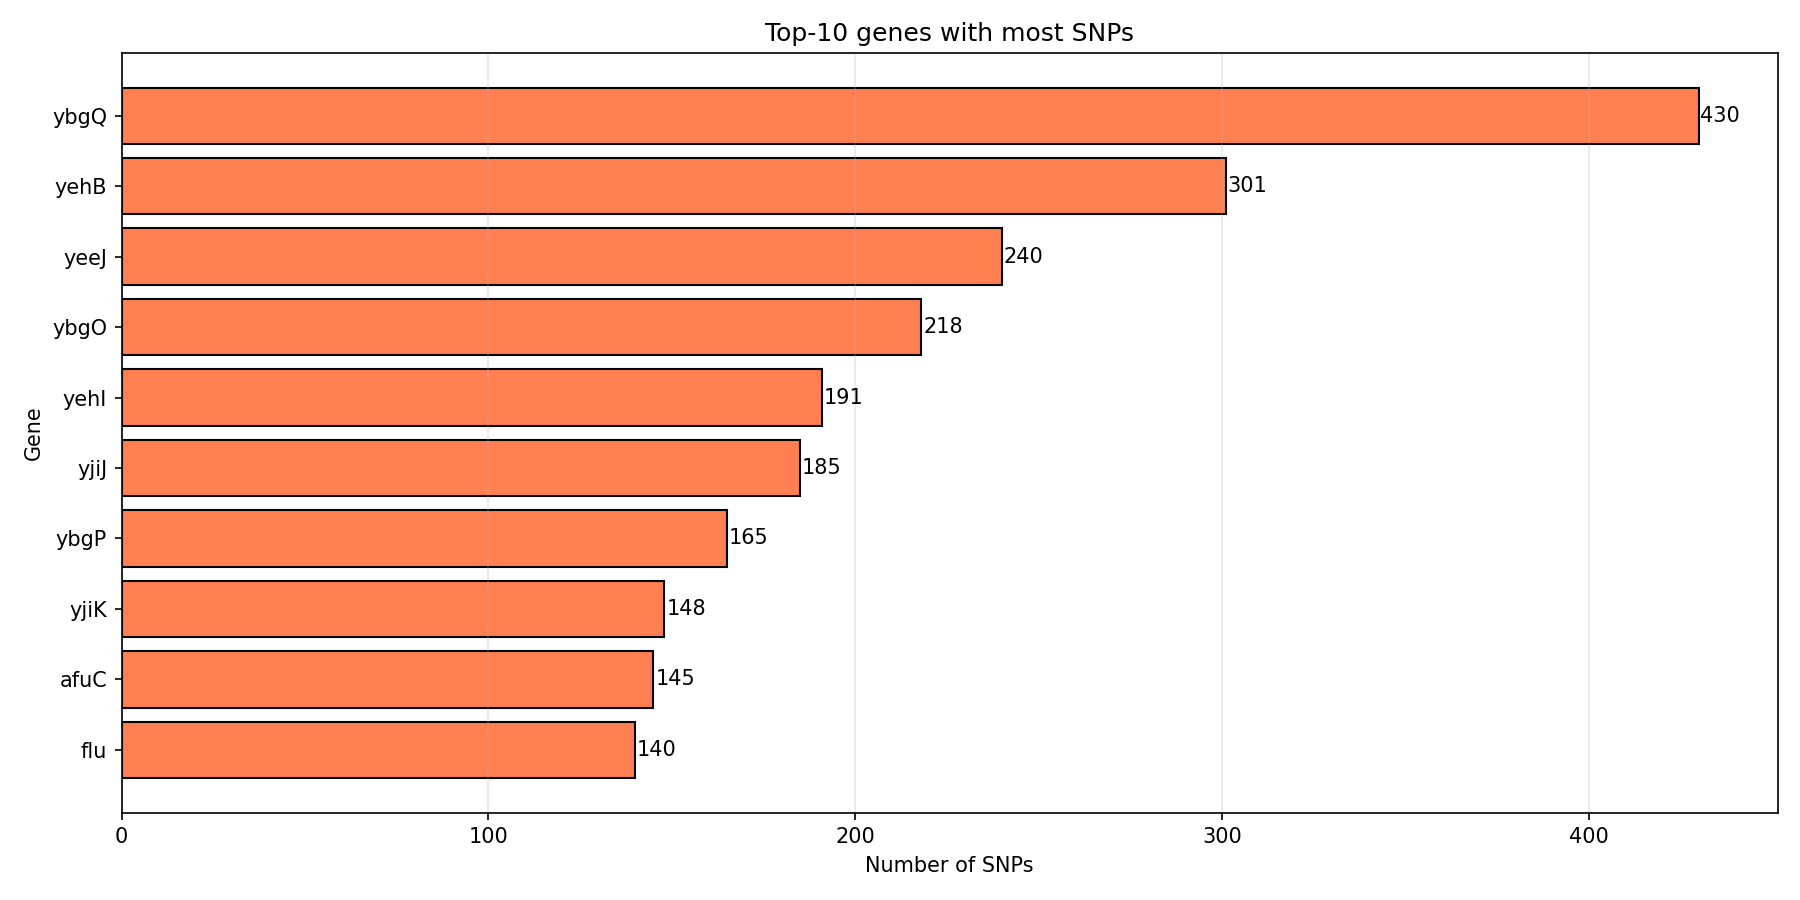

# **Часть 3 -  Поиск функционально значимых SNP**

Опираясь на статью **Whole genome shotgun sequencing revealed highly polymorphic genome regions and genes in Escherichia coli O157:H7 isolates collected from a single feedlot
PLOS One** (https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0202775), пишем скрипт для аннотации SNP в генах устойчивости к антибиотикам.

На выходе получаем статистику по SNP в интересующих нас генах:

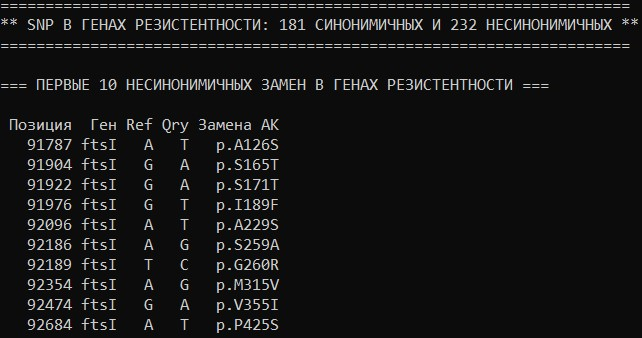

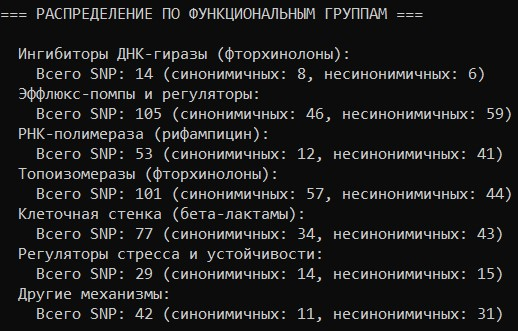

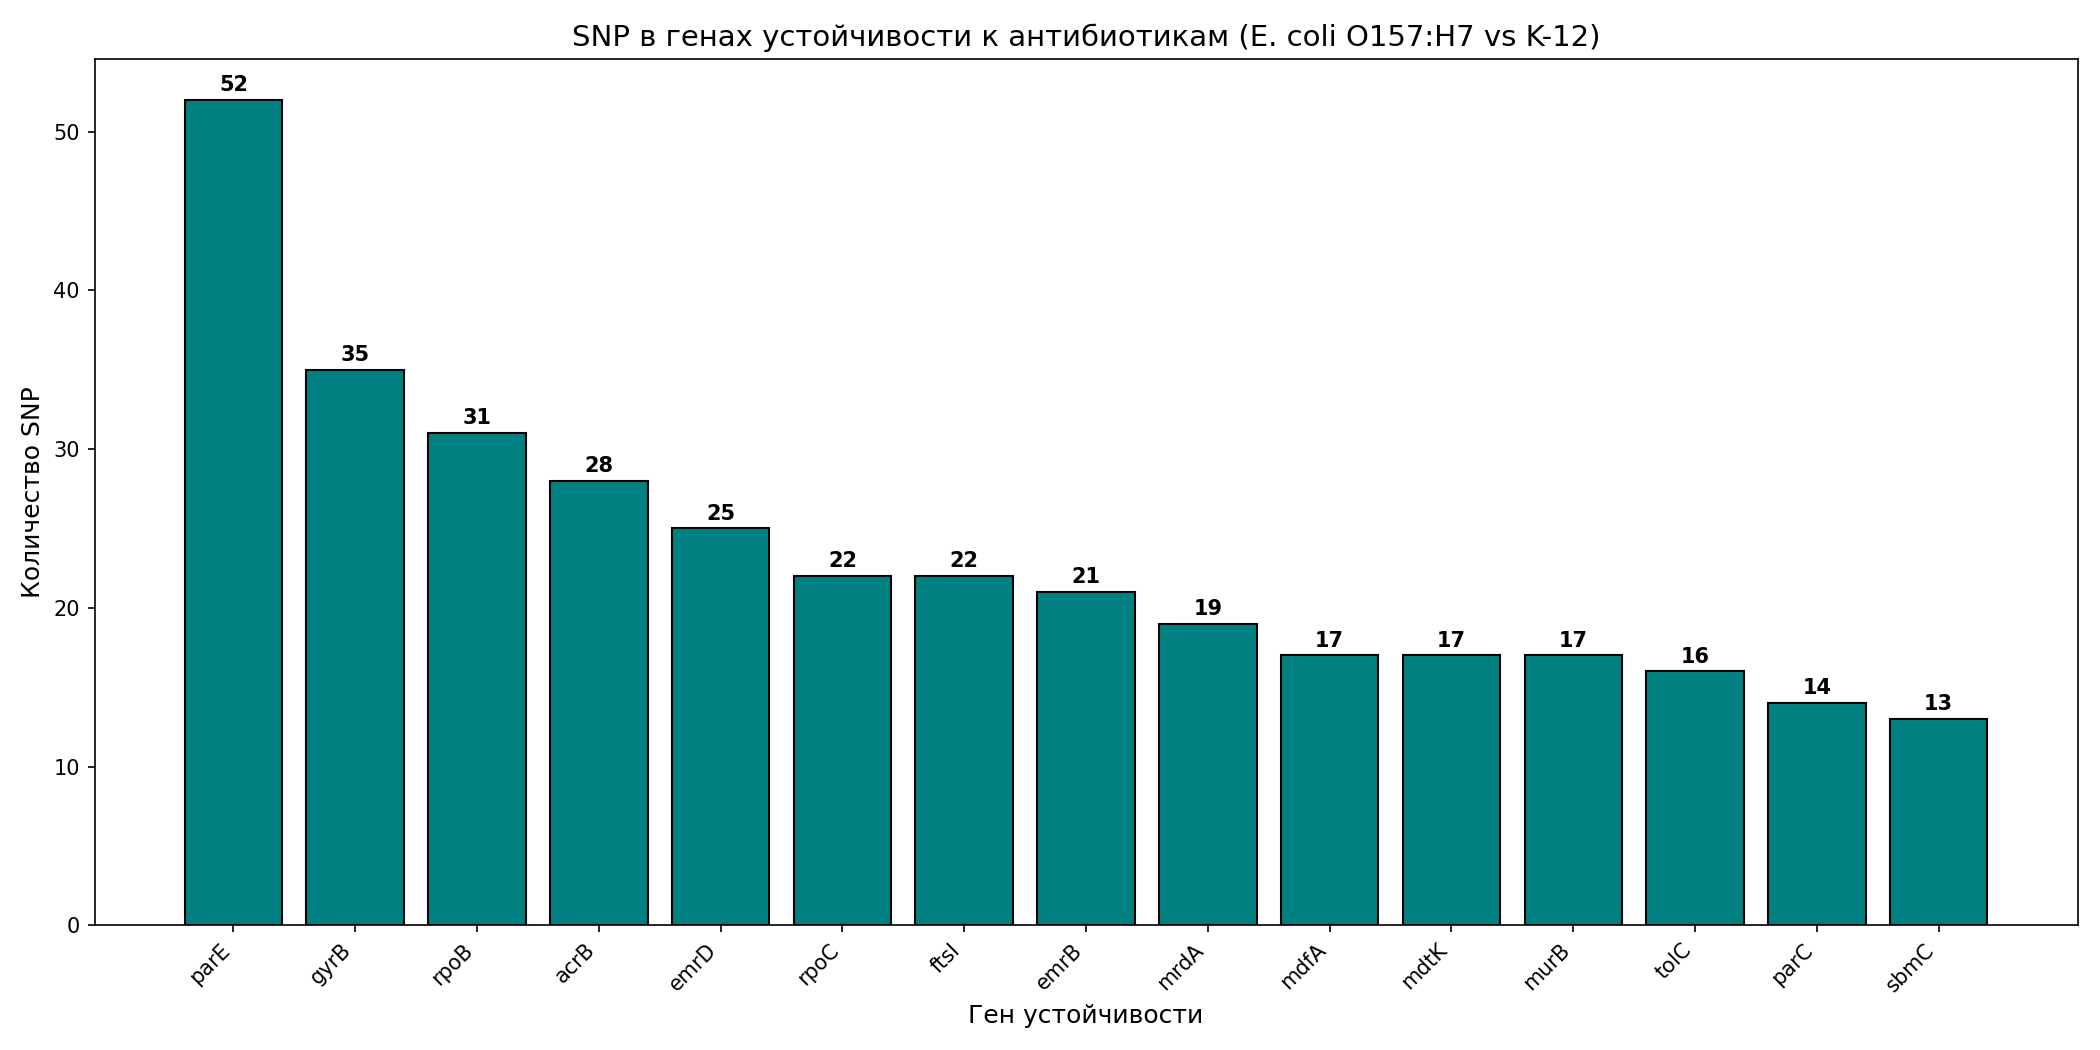

**Как можно было бы применить эти результаты в реальном исследовании :**

- По тому, в каких конкретно генах по функции (скрипт выводит распределение по функциональным группам) находятся SNP (понятное дело, несинонимичные), можно судить о возможных механизмах резистентности к антибиотикам и, соответственно, находить антибиотики, к которым штамм неустойчив.

- Если информации о том, какие гены за что отвечают, нет, то изучение штаммов на разнличные параметры и соотнесение со статистикой по SNP позволяет выявить соответствие генов разным функциям.

- Вообще, важно отслеживать изенения в геноме, чтобы в случае появления опасных штаммов можно было быстро найти новшества и способы борьбы с ними.